**DECISION TREES**

**Example 1**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn import datasets
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target
yt = label_binarize(target, classes=[0, 1, 2])
n_classes = yt.shape[1]
X_train,X_test,Y_train,Y_test = train_test_split(features,target,test_size=0.50,random_state=0)
X_train.shape
X_test.shape
Y_train.shape
Y_test.shape

(75,)

**Example 2**

Predicted Class Probabilities:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]

The accuracy is 100.0%

Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

Classification Report:
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        11
     class 1       1.00      1.00      1.00        13
     class 2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



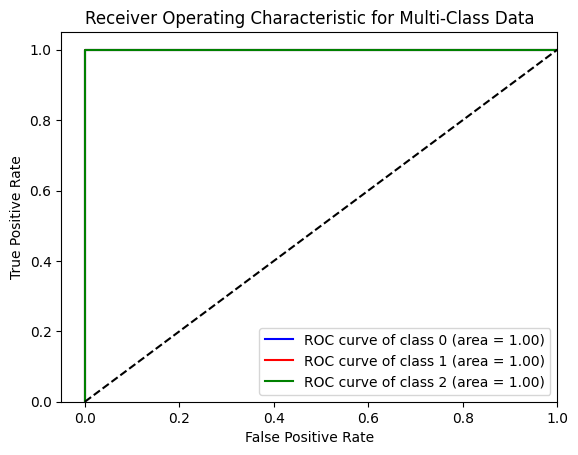


--- Entropy Model ---
Accuracy (Entropy): 100.0%

Confusion Matrix (Entropy):
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

Classification Report (Entropy):
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        11
     class 1       1.00      1.00      1.00        13
     class 2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
# Load libraries
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize          # was missing
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.datasets import load_iris                    # example dataset
from sklearn.model_selection import train_test_split      # was missing
from itertools import cycle

# ─── Load Dataset ─────────────────────────────────────────────────────────────
iris = load_iris()
X = iris.data
Y = iris.target

# ─── Train-Test Split ─────────────────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0)

# ─── Define number of classes ─────────────────────────────────────────────────
n_classes = 3                                             # was missing

# ─── Create & Train Decision Tree (Gini - Default) ───────────────────────────
decisiontree = DecisionTreeClassifier(random_state=0)
model = decisiontree.fit(X_train, Y_train)

# ─── Predict ──────────────────────────────────────────────────────────────────
Y_pred = model.predict(X_test)

# ─── View predicted class probabilities ───────────────────────────────────────
print("Predicted Class Probabilities:")
print(model.predict_proba(X_test))

# ─── Display Metrics ──────────────────────────────────────────────────────────
print("\nThe accuracy is " + str(metrics.accuracy_score(Y_test, Y_pred) * 100) + "%")  # fixed spacing
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))
target_names = ['class 0', 'class 1', 'class 2']
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=target_names))

# ─── ROC Curve (Multi-class) ──────────────────────────────────────────────────
fpr = dict()
tpr = dict()
roc_auc = dict()

# Binarize the output
Y_testt = label_binarize(Y_test, classes=[0, 1, 2])
Y_predd = label_binarize(Y_pred, classes=[0, 1, 2])

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_testt[:, i], Y_predd[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ─── Plot ROC Curve ───────────────────────────────────────────────────────────
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,                # fixed broken string
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class Data')
plt.legend(loc="lower right")
plt.show()

# ─── Decision Tree using Entropy ─────────────────────────────────────────────
decisiontree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0)
model_entropy = decisiontree_entropy.fit(X_train, Y_train)
Y_pred_entropy = model_entropy.predict(X_test)

print("\n--- Entropy Model ---")
print("Accuracy (Entropy): " + str(metrics.accuracy_score(Y_test, Y_pred_entropy) * 100) + "%")
print("\nConfusion Matrix (Entropy):")
print(confusion_matrix(Y_test, Y_pred_entropy))
print("\nClassification Report (Entropy):")
print(classification_report(Y_test, Y_pred_entropy, target_names=target_names))

**Example 3**

In [25]:
# Load libraries
%pip install pydotplus
import pydotplus
from IPython.display import Image
from sklearn import tree
import matplotlib.pyplot as plt

# ─── Create DOT data ──────────────────────────────────────────────────────────
dot_data = tree.export_graphviz(
    decisiontree,                        # fixed broken line continuation
    out_file=None,
    feature_names=iris.feature_names,   # fixed broken line continuation
    class_names=iris.target_names,
    filled=True,                         # added: color nodes by class
    rounded=True,                        # added: rounded boxes
    special_characters=True
)

# ─── Draw Graph ───────────────────────────────────────────────────────────────
graph = pydotplus.graph_from_dot_data(dot_data)

# ─── Show Graph ───────────────────────────────────────────────────────────────
Image(graph.create_png())

# ─── Save Graph as PDF ────────────────────────────────────────────────────────
graph.write_pdf("tree.pdf")
print("Decision Tree saved as tree.pdf")

# ─── Alternative: Plot using matplotlib (if pydotplus not available) ──────────
plt.figure(figsize=(20, 10))
tree.plot_tree(
    decisiontree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Sumba\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


ValueError: Length of feature_names, 4 does not match number of features, 2

**Example 4**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(
iris.data, iris.target, stratify=iris.target, random_state=42)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train,
y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test,
y_test)))
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train,
y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test,
y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.921
Accuracy on training set: 0.991
Accuracy on test set: 0.921


**Example 5**

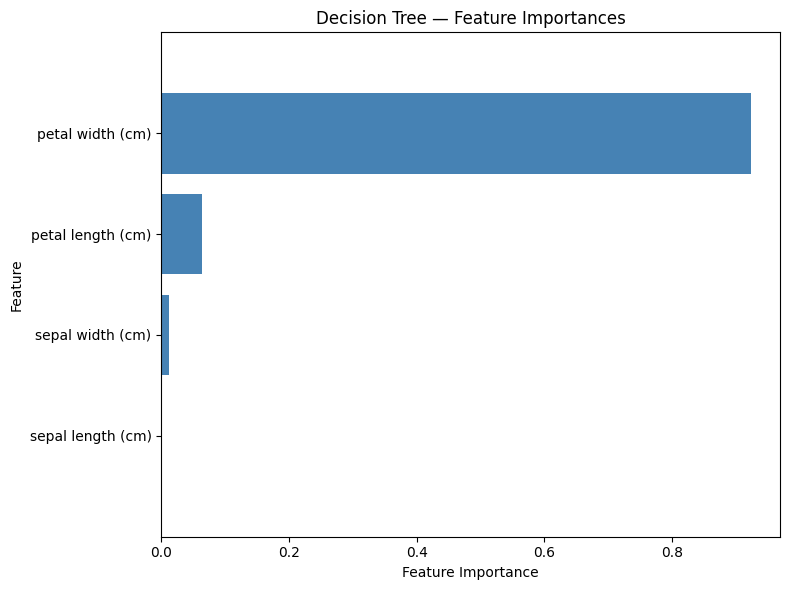

In [ ]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt                            # was missing

# ─── Feature Importance Plot Function ────────────────────────────────────────
def plot_feature_importances(model):
    n_features = iris.data.shape[1]                        # fixed: moved to new line, was joined with plt.barh

    plt.figure(figsize=(8, 6))                             # added: better figure size
    plt.barh(range(n_features), model.feature_importances_,
             align='center',
             color='steelblue')                            # added: color for better visualization
    plt.yticks(np.arange(n_features), iris.feature_names)
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Decision Tree — Feature Importances")       # added: title
    plt.ylim(-1, n_features)
    plt.tight_layout()                                     # added: prevents label cutoff
    plt.show()

# ─── Call Function ────────────────────────────────────────────────────────────
plot_feature_importances(decisiontree)                     # fixed: 'tree' → 'decisiontree'

**Example 6**

Decision Tree Regressor — Results
  R² Score  : -0.3183
  MAE       : 6.7889
  MSE       : 99.9457
  RMSE      : 9.9973


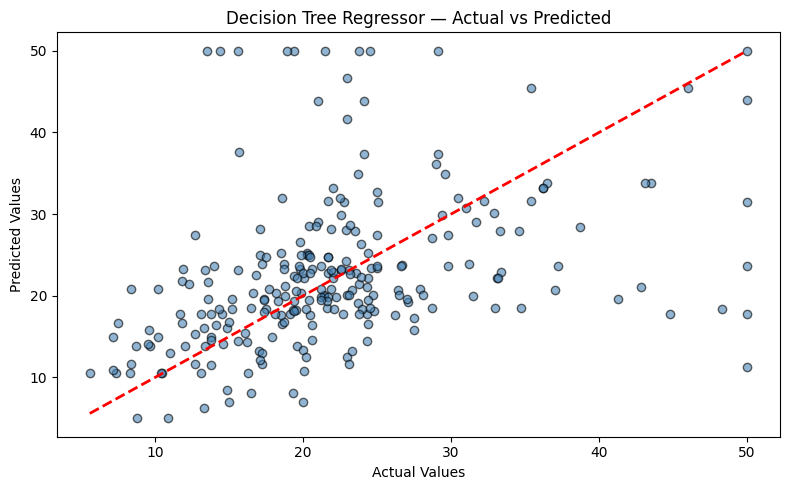

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split      # was missing
from sklearn import metrics

# ─── Load Boston Housing Dataset ─────────────────────────────────────────────
# datasets.load_boston() is removed from sklearn due to ethical concerns
# Loading manually from CMU statistics library instead

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
Y = raw_df.values[1::2, 2]

feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# ─── Use Only First Two Features (as original code intended) ─────────────────
features = X[:, 0:2]
target   = Y

# ─── Train-Test Split ─────────────────────────────────────────────────────────
# fixed: split was broken across two lines
X_train, X_test, Y_train, Y_test = train_test_split(
    features, target,
    test_size=0.50,
    random_state=0
)

# ─── Create & Train Decision Tree Regressor ───────────────────────────────────
decisiontree = DecisionTreeRegressor(random_state=0)
model = decisiontree.fit(X_train, Y_train)

# ─── Predict ──────────────────────────────────────────────────────────────────
Y_pred = model.predict(X_test)

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
print("=" * 45)
print("Decision Tree Regressor — Results")
print("=" * 45)
print(f"  R² Score  : {metrics.r2_score(Y_test, Y_pred):.4f}")
print(f"  MAE       : {metrics.mean_absolute_error(Y_test, Y_pred):.4f}")
print(f"  MSE       : {metrics.mean_squared_error(Y_test, Y_pred):.4f}")
print(f"  RMSE      : {np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)):.4f}")

# ─── Plot Actual vs Predicted ─────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(Y_test, Y_pred, color='steelblue', alpha=0.6, edgecolors='k')
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree Regressor — Actual vs Predicted")
plt.tight_layout()
plt.show()

**Example 7**

Dataset Shape  : (333, 3)
Dataset Columns: ['Unnamed: 0', 'date', 'price']
   Unnamed: 0    date        price
0           0  1957.0  411041792.0
1           1  1959.0   67947725.0
2           2  1960.0    5242880.0
3           3  1965.0    2642412.0
4           4  1970.0     734003.0


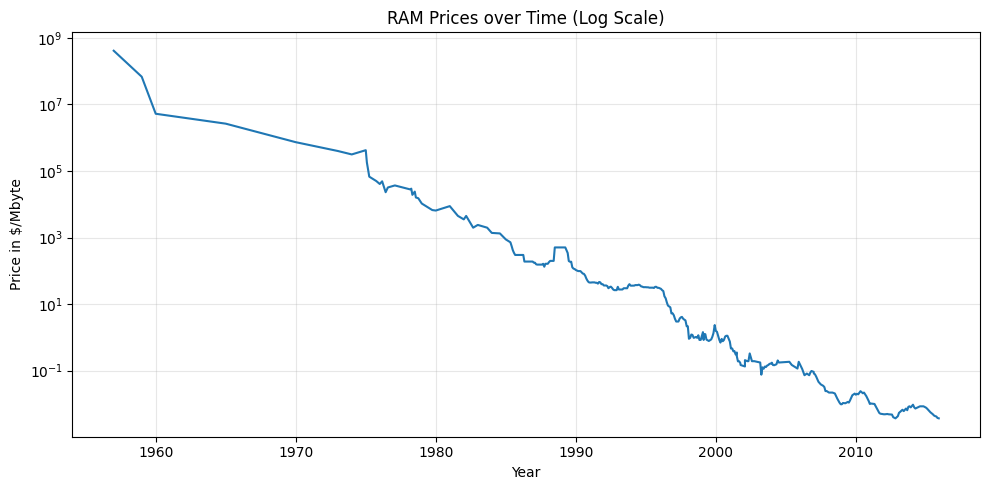

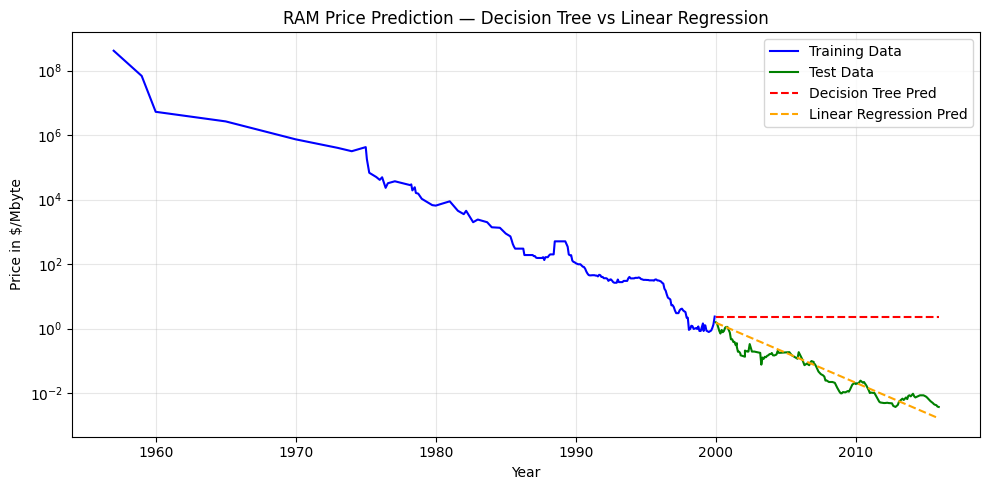

In [ ]:
# Load libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt                           # was missing
import mglearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# ─── Load RAM Price Dataset ───────────────────────────────────────────────────
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, "ram_price.csv"))

print("Dataset Shape  :", ram_prices.shape)
print("Dataset Columns:", ram_prices.columns.tolist())
print(ram_prices.head())

# ─── Plot RAM Prices (Log Scale) ──────────────────────────────────────────────
plt.figure(figsize=(10, 5))                               # added: better figure size
plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel("Year")
plt.ylabel("Price in $/Mbyte")
plt.title("RAM Prices over Time (Log Scale)")             # added: title
plt.grid(True, alpha=0.3)                                 # added: grid for readability
plt.tight_layout()
plt.show()

# ─── Train-Test Split on Date ─────────────────────────────────────────────────
# Train on data before 2000, test on data from 2000 onwards
data_train = ram_prices[ram_prices.date < 2000]
data_test  = ram_prices[ram_prices.date >= 2000]

X_train = data_train.date.values.reshape(-1, 1)
y_train = np.log(data_train.price)                        # log transform for better fitting

X_test  = data_test.date.values.reshape(-1, 1)
y_test  = np.log(data_test.price)

# ─── Decision Tree Regressor ──────────────────────────────────────────────────
tree = DecisionTreeRegressor().fit(X_train, y_train)
pred_tree = tree.predict(X_test)

# ─── Linear Regression ────────────────────────────────────────────────────────
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# ─── Plot Predictions vs Actual ───────────────────────────────────────────────
plt.figure(figsize=(10, 5))

# Training data
plt.semilogy(data_train.date, data_train.price, label="Training Data", color='blue')

# Test data
plt.semilogy(data_test.date, data_test.price, label="Test Data", color='green')

# Decision Tree prediction (convert back from log)
plt.semilogy(data_test.date, np.exp(pred_tree), label="Decision Tree Pred", 
             color='red', linestyle='--')

# Linear Regression prediction (convert back from log)
plt.semilogy(data_test.date, np.exp(pred_lr), label="Linear Regression Pred",
             color='orange', linestyle='--')

plt.xlabel("Year")
plt.ylabel("Price in $/Mbyte")
plt.title("RAM Price Prediction — Decision Tree vs Linear Regression")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Example 8**

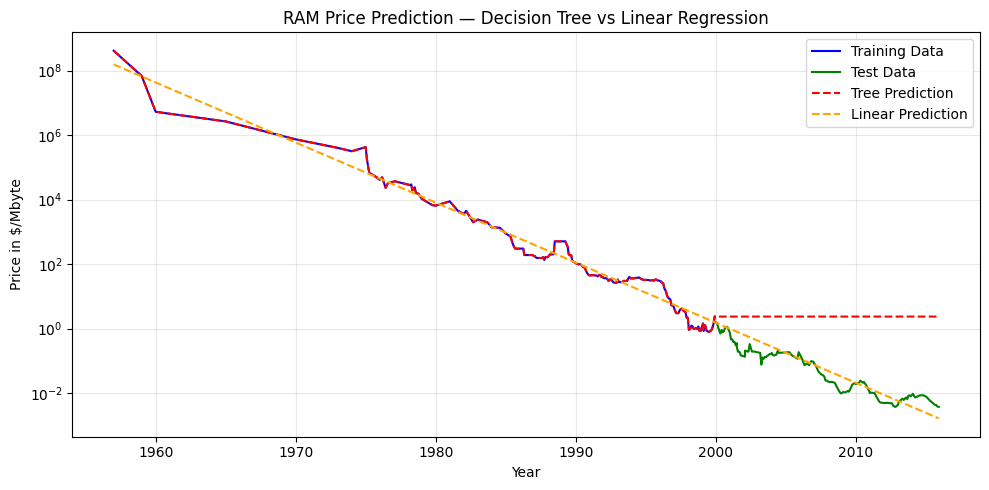

In [ ]:
# Load libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt                           # was missing

# ─── Train-Test Split on Date ─────────────────────────────────────────────────
data_train = ram_prices[ram_prices.date < 2000]
data_test  = ram_prices[ram_prices.date >= 2000]

# ─── Prepare Training Data ────────────────────────────────────────────────────
X_train = data_train.date.values[:, np.newaxis]          # fixed: added .values to avoid pandas indexing error
y_train = np.log(data_train.price)

# ─── Train Models ─────────────────────────────────────────────────────────────
tree       = DecisionTreeRegressor().fit(X_train, y_train)
linear_reg = LinearRegression().fit(X_train, y_train)

# ─── Predict on All Data ──────────────────────────────────────────────────────
X_all     = ram_prices.date.values[:, np.newaxis]        # fixed: added .values to avoid pandas indexing error
pred_tree = tree.predict(X_all)
pred_lr   = linear_reg.predict(X_all)

# ─── Undo Log Transform ───────────────────────────────────────────────────────
price_tree = np.exp(pred_tree)
price_lr   = np.exp(pred_lr)

# ─── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))                               # added: better figure size
plt.semilogy(data_train.date, data_train.price,
             label="Training Data",                       # fixed: broken string across two lines
             color='blue')
plt.semilogy(data_test.date, data_test.price,
             label="Test Data",
             color='green')
plt.semilogy(ram_prices.date, price_tree,
             label="Tree Prediction",
             color='red', linestyle='--')
plt.semilogy(ram_prices.date, price_lr,
             label="Linear Prediction",
             color='orange', linestyle='--')

plt.xlabel("Year")                                        # added: axis labels
plt.ylabel("Price in $/Mbyte")                           # added: axis labels
plt.title("RAM Price Prediction — Decision Tree vs Linear Regression")  # added: title
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)                                 # added: grid for readability
plt.tight_layout()                                        # added: prevents label cutoff
plt.show()

Questions and their implementation


  Dataset: Iris
  Accuracy  : 100.00%

  Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

  Classification Report:
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        11
     class 1       1.00      1.00      1.00        13
     class 2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


  Dataset: Wine
  Accuracy  : 97.22%

  Confusion Matrix:
[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]

  Classification Report:
              precision    recall  f1-score   support

     class 0       0.93      1.00      0.97        14
     class 1       1.00      0.94      0.97        16
     class 2       1.00      1.00      1.00         6

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97     

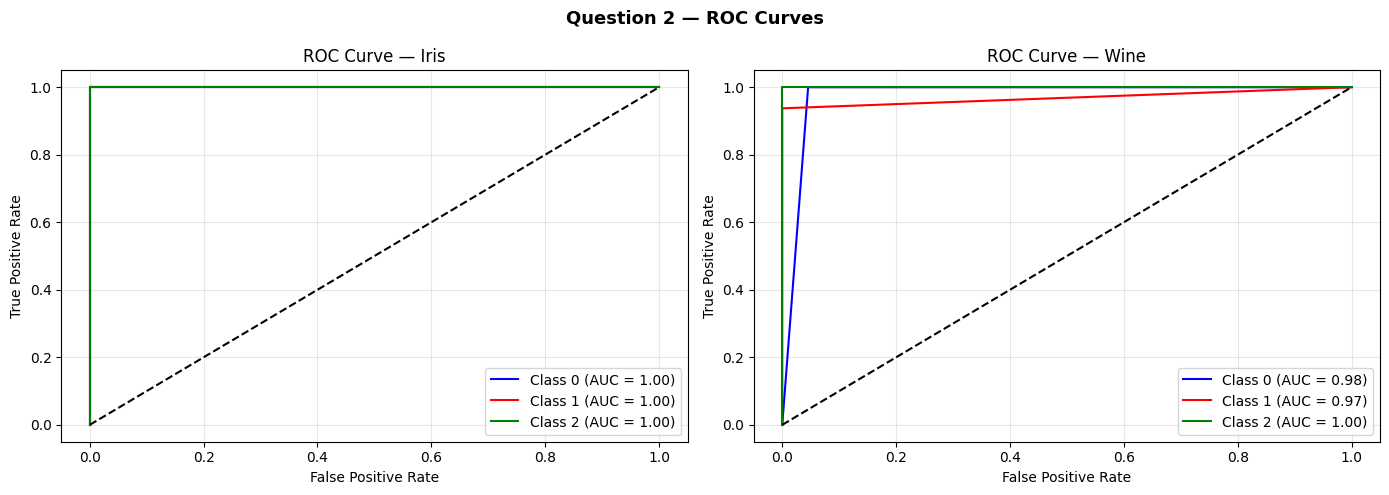

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris, load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score)
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ─── Helper Functions ─────────────────────────────────────────────────────────
def evaluate_model(name, y_test, y_pred, n_classes):
    print(f"\n{'='*55}")
    print(f"  Dataset: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
    print("\n  Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n  Classification Report:")
    target_names = [f'class {i}' for i in range(n_classes)]
    print(classification_report(y_test, y_pred, target_names=target_names))

def plot_roc(name, y_test, y_pred, n_classes, ax):
    y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
    y_pred_bin = label_binarize(y_pred, classes=list(range(n_classes)))
    colors = cycle(['blue', 'red', 'green', 'orange'])
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color,
                label=f'Class {i} (AUC = {roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {name}")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

# ─── Load Datasets ────────────────────────────────────────────────────────────
datasets = {
    "Iris": load_iris(),
    "Wine": load_wine()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Question 2 — ROC Curves", fontsize=13, fontweight='bold')

for ax, (dname, data) in zip(axes, datasets.items()):
    X, y       = data.data, data.target
    n_classes  = len(np.unique(y))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0)

    model  = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
    y_pred = model.predict(X_test)

    evaluate_model(dname, y_test, y_pred, n_classes)
    plot_roc(dname, y_test, y_pred, n_classes, ax)

plt.tight_layout()
plt.show()


  Dataset: Iris
  Model           Train Acc     Test Acc
  ------------------------------------
  Unpruned          100.00%      100.00%
  Depth=3            96.67%       96.67%
  Depth=4            99.17%      100.00%
  Depth=5           100.00%      100.00%

  Dataset: Wine
  Model           Train Acc     Test Acc
  ------------------------------------
  Unpruned          100.00%       97.22%
  Depth=3            99.30%       97.22%
  Depth=4           100.00%       97.22%
  Depth=5           100.00%       97.22%


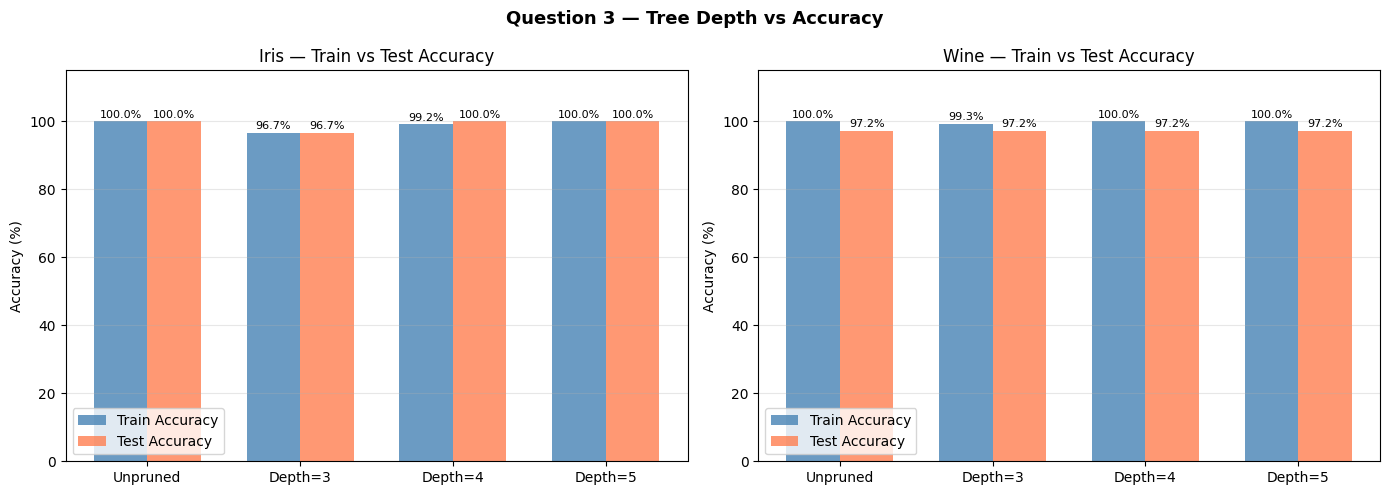

In [27]:
# ─── Tree Depths to Analyze ───────────────────────────────────────────────────
depths      = [None, 3, 4, 5]       # None = unpruned
depth_labels= ['Unpruned', 'Depth=3', 'Depth=4', 'Depth=5']

results = {}

for dname, data in datasets.items():
    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0)

    train_accs, test_accs = [], []

    print(f"\n{'='*55}")
    print(f"  Dataset: {dname}")
    print(f"{'='*55}")
    print(f"  {'Model':<12} {'Train Acc':>12} {'Test Acc':>12}")
    print(f"  {'-'*36}")

    for depth, label in zip(depths, depth_labels):
        clf        = DecisionTreeClassifier(max_depth=depth, random_state=0)
        clf.fit(X_train, y_train)
        train_acc  = accuracy_score(y_train, clf.predict(X_train)) * 100
        test_acc   = accuracy_score(y_test,  clf.predict(X_test))  * 100
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"  {label:<12} {train_acc:>11.2f}% {test_acc:>11.2f}%")

    results[dname] = (train_accs, test_accs)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Question 3 — Tree Depth vs Accuracy", fontsize=13, fontweight='bold')

x = np.arange(len(depth_labels))
width = 0.35

for ax, (dname, (train_accs, test_accs)) in zip(axes, results.items()):
    bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy',
                   color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',
                   color='coral',     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(depth_labels)
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 115)
    ax.set_title(f"{dname} — Train vs Test Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

  Question 5 — Linear vs Tree Regression (60:40 Split)
  Dataset          Model                        R²        MRE
  ----------------------------------------------------------
  Wave             Linear Regression        0.5932    16.3480
  Wave             Decision Tree            0.8353     3.8723
  RAM Prices       Linear Regression        0.9777     0.5074
  RAM Prices       Decision Tree            0.9963     0.1927
  Boston Housing   Linear Regression        0.7125     0.1700
  Boston Housing   Decision Tree            0.6898     0.1769


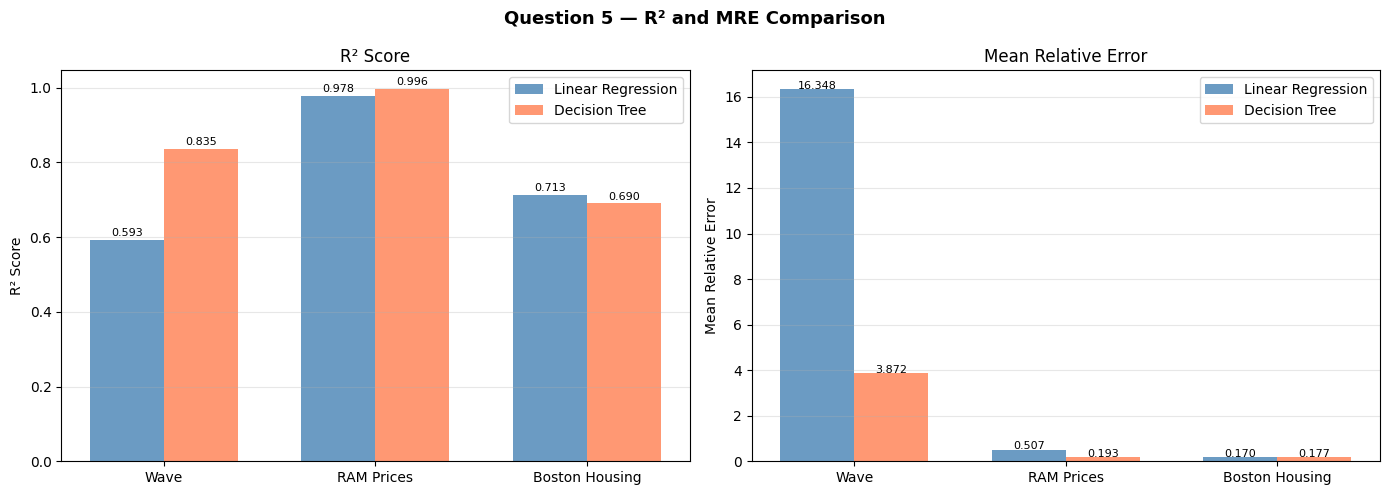

In [28]:
import os
import pandas as pd
import mglearn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ─── Helper Functions ─────────────────────────────────────────────────────────
def mean_relative_error(actual, predicted):
    return np.mean(np.abs(predicted - actual) / np.abs(actual))

def make_wave(n_samples=100):
    np.random.seed(42)
    X = np.random.uniform(-3, 3, (n_samples, 1))
    y = np.sin(X).ravel() + np.random.normal(0, 0.3, n_samples)
    return X, y

# ─── Load Datasets ────────────────────────────────────────────────────────────
# Wave
X_wave, y_wave = make_wave(n_samples=100)

# RAM Prices
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, "ram_price.csv"))
X_ram = ram_prices.date.values[:, np.newaxis]
y_ram = np.log(ram_prices.price.values)

# Boston Housing
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df   = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X_boston = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y_boston = raw_df.values[1::2, 2]

all_datasets = {
    "Wave":           (X_wave,   y_wave),
    "RAM Prices":     (X_ram,    y_ram),
    "Boston Housing": (X_boston, y_boston),
}

# ─── Train & Evaluate ─────────────────────────────────────────────────────────
print(f"{'='*65}")
print(f"  Question 5 — Linear vs Tree Regression (60:40 Split)")
print(f"{'='*65}")
print(f"  {'Dataset':<16} {'Model':<22} {'R²':>8} {'MRE':>10}")
print(f"  {'-'*58}")

q5_results = {}

for dname, (X, y) in all_datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.40, random_state=42)

    q5_results[dname] = {}

    for mname, model in [("Linear Regression", LinearRegression()),
                          ("Decision Tree",     DecisionTreeRegressor(random_state=0))]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2     = r2_score(y_test, y_pred)
        mre    = mean_relative_error(y_test, y_pred)
        q5_results[dname][mname] = (r2, mre)
        print(f"  {dname:<16} {mname:<22} {r2:>8.4f} {mre:>10.4f}")

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Question 5 — R² and MRE Comparison", fontsize=13, fontweight='bold')

dnames = list(q5_results.keys())
models = ["Linear Regression", "Decision Tree"]
x      = np.arange(len(dnames))
width  = 0.35
colors = ['steelblue', 'coral']

for ax, metric_idx, ylabel in zip(axes, [0, 1], ["R² Score", "Mean Relative Error"]):
    for j, (mname, color) in enumerate(zip(models, colors)):
        vals = [q5_results[d][mname][metric_idx] for d in dnames]
        bars = ax.bar(x + j*width - width/2, vals, width,
                      label=mname, color=color, alpha=0.8)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(dnames)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


  Question 6 — Tree Depth vs MRE (60:40 Split)

  Dataset : Wave
  Model           Train MRE     Test MRE
  --------------------------------------
  Unpruned           0.0000       3.8723
  Depth=3            0.8608       7.5932
  Depth=4            0.7285       6.2628
  Depth=5            0.3391       5.3760

  Dataset : RAM Prices
  Model           Train MRE     Test MRE
  --------------------------------------
  Unpruned           0.0000       0.1927
  Depth=3            0.5228       0.4097
  Depth=4            0.2169       0.1792
  Depth=5            0.2314       0.2223

  Dataset : Boston Housing
  Model           Train MRE     Test MRE
  --------------------------------------
  Unpruned           0.0000       0.1769
  Depth=3            0.1451       0.1889
  Depth=4            0.1078       0.1668
  Depth=5            0.0906       0.1413


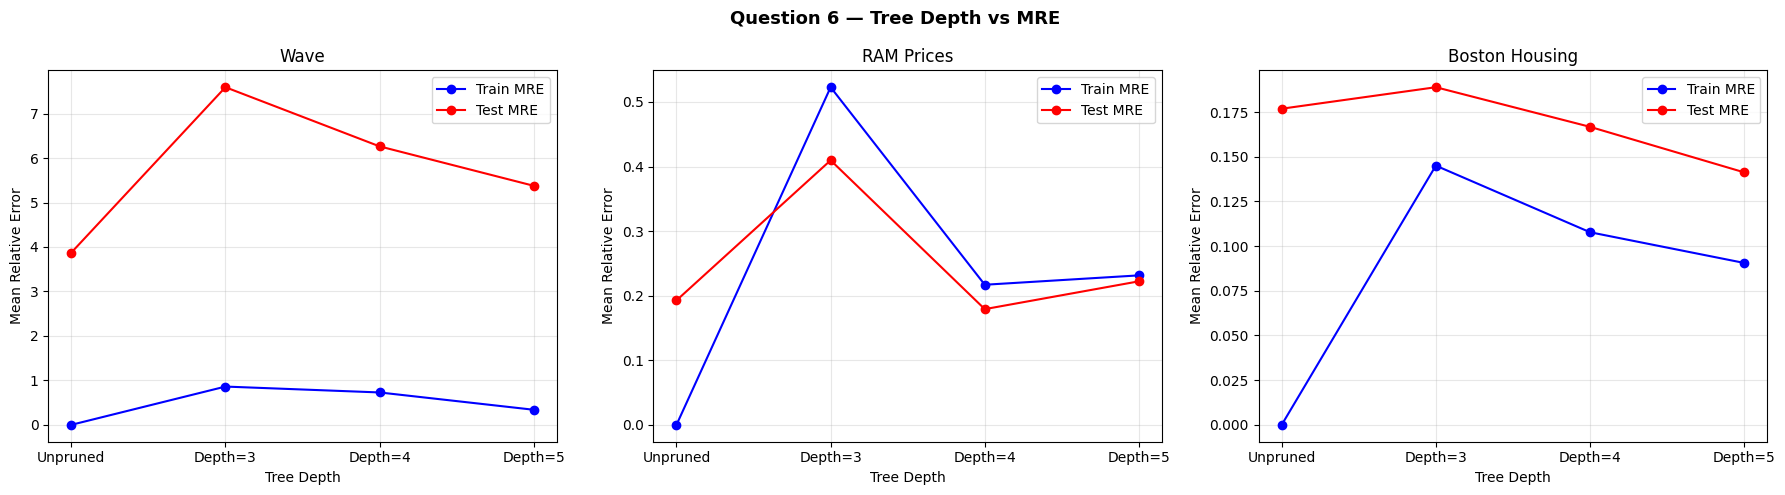

In [29]:
depths       = [None, 3, 4, 5]
depth_labels = ['Unpruned', 'Depth=3', 'Depth=4', 'Depth=5']

print(f"\n{'='*65}")
print(f"  Question 6 — Tree Depth vs MRE (60:40 Split)")
print(f"{'='*65}")

q6_results = {}

for dname, (X, y) in all_datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.40, random_state=42)

    q6_results[dname] = {'train': [], 'test': []}

    print(f"\n  Dataset : {dname}")
    print(f"  {'Model':<12} {'Train MRE':>12} {'Test MRE':>12}")
    print(f"  {'-'*38}")

    for depth, label in zip(depths, depth_labels):
        model = DecisionTreeRegressor(max_depth=depth, random_state=0)
        model.fit(X_train, y_train)
        train_mre = mean_relative_error(y_train, model.predict(X_train))
        test_mre  = mean_relative_error(y_test,  model.predict(X_test))
        q6_results[dname]['train'].append(train_mre)
        q6_results[dname]['test'].append(test_mre)
        print(f"  {label:<12} {train_mre:>12.4f} {test_mre:>12.4f}")

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Question 6 — Tree Depth vs MRE", fontsize=13, fontweight='bold')

for ax, dname in zip(axes, all_datasets.keys()):
    ax.plot(depth_labels, q6_results[dname]['train'],
            'b-o', label='Train MRE')
    ax.plot(depth_labels, q6_results[dname]['test'],
            'r-o', label='Test MRE')
    ax.set_title(dname)
    ax.set_xlabel("Tree Depth")
    ax.set_ylabel("Mean Relative Error")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()